# DATA PREPARATION — Class Imbalance & SMOTE
## Penerapan Teknik SMOTE untuk Mengatasi Class Imbalance dalam Prediksi Customer Churn

---
| | |
|---|---|
| **Nama** | Zahirah Salsabila (124230164) · Amri Sabilly (124230147) · Faqih Aulia A.D. (124230150) |
| **Dosen** | Daniel Eliazar Latumaerissa, S.Pd., M.Si.D. |
| **Prodi** | Sistem Informasi — UPN Veteran Yogyakarta |
| **Dataset** | [E-Commerce Customer Churn — Kaggle (Verma, 2021)](https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction) |

---
### Alur Kerja Notebook Ini

```
LOAD DATA
   │
   ▼
PRE-PROCESSING (persiapan sebelum SMOTE)
   │  ├─ Cleaning dirty data (inkonsistensi string)
   │  ├─ Imputasi missing values (median)
   │  └─ Encoding + Feature Scaling
   │
   ▼
TRAIN-TEST SPLIT  (stratified 80:20)
   │
   ▼
ANALISIS CLASS IMBALANCE
   │  ├─ Distribusi target Churn
   │  ├─ Rasio Non-Churn vs Churn
   │  └─ Visualisasi sebelum SMOTE
   │
   ▼
TERAPKAN SMOTE (hanya pada data training)
   │
   ▼
EVALUASI HASIL OVERSAMPLING
   │  ├─ Distribusi setelah SMOTE
   │  ├─ Perbandingan sebelum vs sesudah
   │  └─ Visualisasi PCA 2D
   │
   ▼
DOKUMENTASI PARAMETER SMOTE
```

---
## 0. Import Library

In [1]:
# ══════════════════════════════════════════════════════════════════
#  CELL 0 — Import Library
# ══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.decomposition  import PCA
from imblearn.over_sampling import SMOTE
from collections            import Counter

warnings.filterwarnings('ignore')

# ── Gaya visual global ────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'     : 130,
    'axes.titlesize' : 12,
    'axes.labelsize' : 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'font.family'    : 'sans-serif',
})

C_MAJORITY = '#4472C4'   # biru  → Non-Churn
C_MINORITY = '#ED7D31'   # oranye → Churn
C_SMOTE    = '#70AD47'   # hijau  → data sintetis SMOTE
C_DANGER   = '#C00000'   # merah  → peringatan

print('✅ Library berhasil diimport.')
print('   Versi imbalanced-learn :', __import__('imblearn').__version__)
print('   Versi scikit-learn     :', __import__('sklearn').__version__)

✅ Library berhasil diimport.
   Versi imbalanced-learn : 0.14.1
   Versi scikit-learn     : 1.8.0


---
## 1. Load Dataset

In [2]:
# ══════════════════════════════════════════════════════════════════
#  CELL 1 — Load Dataset
#  Ganti FILE_PATH sesuai lokasi file di komputer Anda
# ══════════════════════════════════════════════════════════════════
FILE_PATH = './store/E_Commerce_Dataset.xlsx'      # <── sesuaikan path

df_raw = pd.read_excel(FILE_PATH, sheet_name='E Comm')
df     = df_raw.copy()             # simpan salinan mentah

print(f'✅ Dataset dimuat  →  {df.shape[0]:,} baris  ×  {df.shape[1]} kolom')
df.head(3)

✅ Dataset dimuat  →  5,630 baris  ×  20 kolom


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28


---
## 2. Pre-Processing (Persiapan Sebelum SMOTE)
> Tahap ini **wajib diselesaikan** sebelum SMOTE diterapkan, karena SMOTE memerlukan data numerik yang bersih dan lengkap.

### 2.1 Cleaning Dirty Data — Standardisasi String Kategorikal

In [3]:
# ══════════════════════════════════════════════════════════════════
#  CELL 2.1 — Cleaning Inkonsistensi String (Dirty Data)
#  Sumber: Tabel 2.2 Laporan — Isu Inkonsistensi
# ══════════════════════════════════════════════════════════════════

# ── Sebelum cleaning: tampilkan unique values ─────────────────────
print('Sebelum cleaning:')
print('  PreferredPaymentMode :', sorted(df['PreferredPaymentMode'].dropna().unique()))
print('  PreferedOrderCat     :', sorted(df['PreferedOrderCat'].dropna().unique()))

# ── Peta standarisasi (sesuai laporan BAB II) ─────────────────────
payment_map = {
    'CC'             : 'Credit Card',
    'COD'            : 'Cash on Delivery',
}
order_cat_map = {
    'Mobile'         : 'Mobile Phone',
}

df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace(payment_map)
df['PreferedOrderCat']     = df['PreferedOrderCat'].replace(order_cat_map)

# ── Sesudah cleaning ──────────────────────────────────────────────
print('\nSesudah cleaning:')
print('  PreferredPaymentMode :', sorted(df['PreferredPaymentMode'].dropna().unique()))
print('  PreferedOrderCat     :', sorted(df['PreferedOrderCat'].dropna().unique()))
print('\n✅ Inkonsistensi string berhasil distandardisasi.')

Sebelum cleaning:
  PreferredPaymentMode : ['CC', 'COD', 'Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']
  PreferedOrderCat     : ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others']

Sesudah cleaning:
  PreferredPaymentMode : ['Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']
  PreferedOrderCat     : ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile Phone', 'Others']

✅ Inkonsistensi string berhasil distandardisasi.


### 2.2 Imputasi Missing Values (Median)

In [4]:
# ══════════════════════════════════════════════════════════════════
#  CELL 2.2 — Imputasi Missing Values dengan Median
#  Sumber: Tabel 2.2 Laporan — 7 kolom dengan missing values
# ══════════════════════════════════════════════════════════════════

missing_before = df.isnull().sum()
missing_cols   = missing_before[missing_before > 0]

print('Missing values sebelum imputasi:')
print(missing_cols.to_string())
print(f'\nTotal nilai kosong: {missing_cols.sum()}')

# Imputasi median hanya untuk kolom numerik yang memiliki missing values
for col in missing_cols.index:
    if df[col].dtype in [np.float64, np.int64]:
        median_val = df[col].median()
        df[col]    = df[col].fillna(median_val)
        print(f'  → [{col}] diimputasi dengan median = {median_val:.2f}')

missing_after = df.isnull().sum().sum()
print(f'\n✅ Total missing values setelah imputasi: {missing_after}')

Missing values sebelum imputasi:
Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307

Total nilai kosong: 1856
  → [Tenure] diimputasi dengan median = 9.00
  → [WarehouseToHome] diimputasi dengan median = 14.00
  → [HourSpendOnApp] diimputasi dengan median = 3.00
  → [OrderAmountHikeFromlastYear] diimputasi dengan median = 15.00
  → [CouponUsed] diimputasi dengan median = 1.00
  → [OrderCount] diimputasi dengan median = 2.00
  → [DaySinceLastOrder] diimputasi dengan median = 3.00

✅ Total missing values setelah imputasi: 0


### 2.3 Encoding Fitur Kategorikal & Hapus Kolom Tidak Relevan

In [5]:
# ══════════════════════════════════════════════════════════════════
#  CELL 2.3 — Label Encoding & Drop Kolom Tidak Relevan
# ══════════════════════════════════════════════════════════════════

# CustomerID tidak relevan untuk pemodelan
df = df.drop(columns=['CustomerID'], errors='ignore')

# Identifikasi kolom kategorikal
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Kolom kategorikal yang akan di-encode ({len(cat_cols)} kolom):')
for col in cat_cols:
    uq = df[col].nunique()
    print(f'  [{col}] → {uq} kategori unik: {df[col].unique().tolist()}')

# Label Encoding
le       = LabelEncoder()
le_info  = {}
for col in cat_cols:
    df[col]     = le.fit_transform(df[col].astype(str))
    le_info[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print('\n✅ Encoding selesai.')
print(f'   Shape sekarang: {df.shape[0]:,} baris × {df.shape[1]} kolom')

Kolom kategorikal yang akan di-encode (5 kolom):
  [PreferredLoginDevice] → 3 kategori unik: ['Mobile Phone', 'Phone', 'Computer']
  [PreferredPaymentMode] → 5 kategori unik: ['Debit Card', 'UPI', 'Credit Card', 'Cash on Delivery', 'E wallet']
  [Gender] → 2 kategori unik: ['Female', 'Male']
  [PreferedOrderCat] → 5 kategori unik: ['Laptop & Accessory', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']
  [MaritalStatus] → 3 kategori unik: ['Single', 'Divorced', 'Married']

✅ Encoding selesai.
   Shape sekarang: 5,630 baris × 19 kolom


### 2.4 Pisah Fitur & Target → Train-Test Split (80:20 Stratified)

In [6]:
# ══════════════════════════════════════════════════════════════════
#  CELL 2.4 — Train-Test Split (stratified 80:20)
#  SMOTE HANYA diterapkan pada data training!
# ══════════════════════════════════════════════════════════════════

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y          # jaga proporsi kelas
)

print('✅ Train-Test Split (80:20, stratified):')
print(f'   X_train : {X_train.shape[0]:,} baris  |  X_test : {X_test.shape[0]:,} baris')
print(f'\n   Distribusi y_train:')
print(f'     Non-Churn (0) : {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.1f}%)')
print(f'     Churn     (1) : {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.1f}%)')
print(f'\n   Distribusi y_test:')
print(f'     Non-Churn (0) : {(y_test==0).sum():,}  ({(y_test==0).mean()*100:.1f}%)')
print(f'     Churn     (1) : {(y_test==1).sum():,}  ({(y_test==1).mean()*100:.1f}%)')

✅ Train-Test Split (80:20, stratified):
   X_train : 4,504 baris  |  X_test : 1,126 baris

   Distribusi y_train:
     Non-Churn (0) : 3,746  (83.2%)
     Churn     (1) : 758  (16.8%)

   Distribusi y_test:
     Non-Churn (0) : 936  (83.1%)
     Churn     (1) : 190  (16.9%)


---
## 3. Analisis Class Imbalance (Sebelum SMOTE)

### 3.1 Distribusi Variabel Target & Rasio Ketidakseimbangan

In [7]:
# ══════════════════════════════════════════════════════════════════
#  CELL 3.1 — Analisis Distribusi & Rasio Class Imbalance
# ══════════════════════════════════════════════════════════════════

total       = len(y_train)
n_majority  = (y_train == 0).sum()    # Non-Churn
n_minority  = (y_train == 1).sum()    # Churn
ratio       = n_majority / n_minority
pct_maj     = n_majority / total * 100
pct_min     = n_minority / total * 100

print('╔══════════════════════════════════════════════════════════════╗')
print('║          ANALISIS CLASS IMBALANCE — DATA TRAINING           ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Total data training     : {total:,} sampel')
print(f'║  Non-Churn (Mayoritas)   : {n_majority:,}  ({pct_maj:.1f}%)')
print(f'║  Churn     (Minoritas)   : {n_minority:,}  ({pct_min:.1f}%)')
print(f'║  Rasio Imbalance         : 1 : {ratio:.1f}  (Churn : Non-Churn)')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  DAMPAK CLASS IMBALANCE:')
print('║  • Algoritma bias ke kelas mayoritas (Non-Churn)')
print(f'║  • Model bisa mencapai akurasi {pct_maj:.1f}% hanya dengan')
print('║    memprediksi semua data sebagai Non-Churn')
print('║  • Recall dan F1-Score untuk kelas Churn akan sangat rendah')
print('║  • Solusi: SMOTE (Synthetic Minority Oversampling Technique)')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║          ANALISIS CLASS IMBALANCE — DATA TRAINING           ║
╠══════════════════════════════════════════════════════════════╣
║  Total data training     : 4,504 sampel
║  Non-Churn (Mayoritas)   : 3,746  (83.2%)
║  Churn     (Minoritas)   : 758  (16.8%)
║  Rasio Imbalance         : 1 : 4.9  (Churn : Non-Churn)
╠══════════════════════════════════════════════════════════════╣
║  DAMPAK CLASS IMBALANCE:
║  • Algoritma bias ke kelas mayoritas (Non-Churn)
║  • Model bisa mencapai akurasi 83.2% hanya dengan
║    memprediksi semua data sebagai Non-Churn
║  • Recall dan F1-Score untuk kelas Churn akan sangat rendah
║  • Solusi: SMOTE (Synthetic Minority Oversampling Technique)
╚══════════════════════════════════════════════════════════════╝


### 3.2 Visualisasi Class Imbalance Sebelum SMOTE

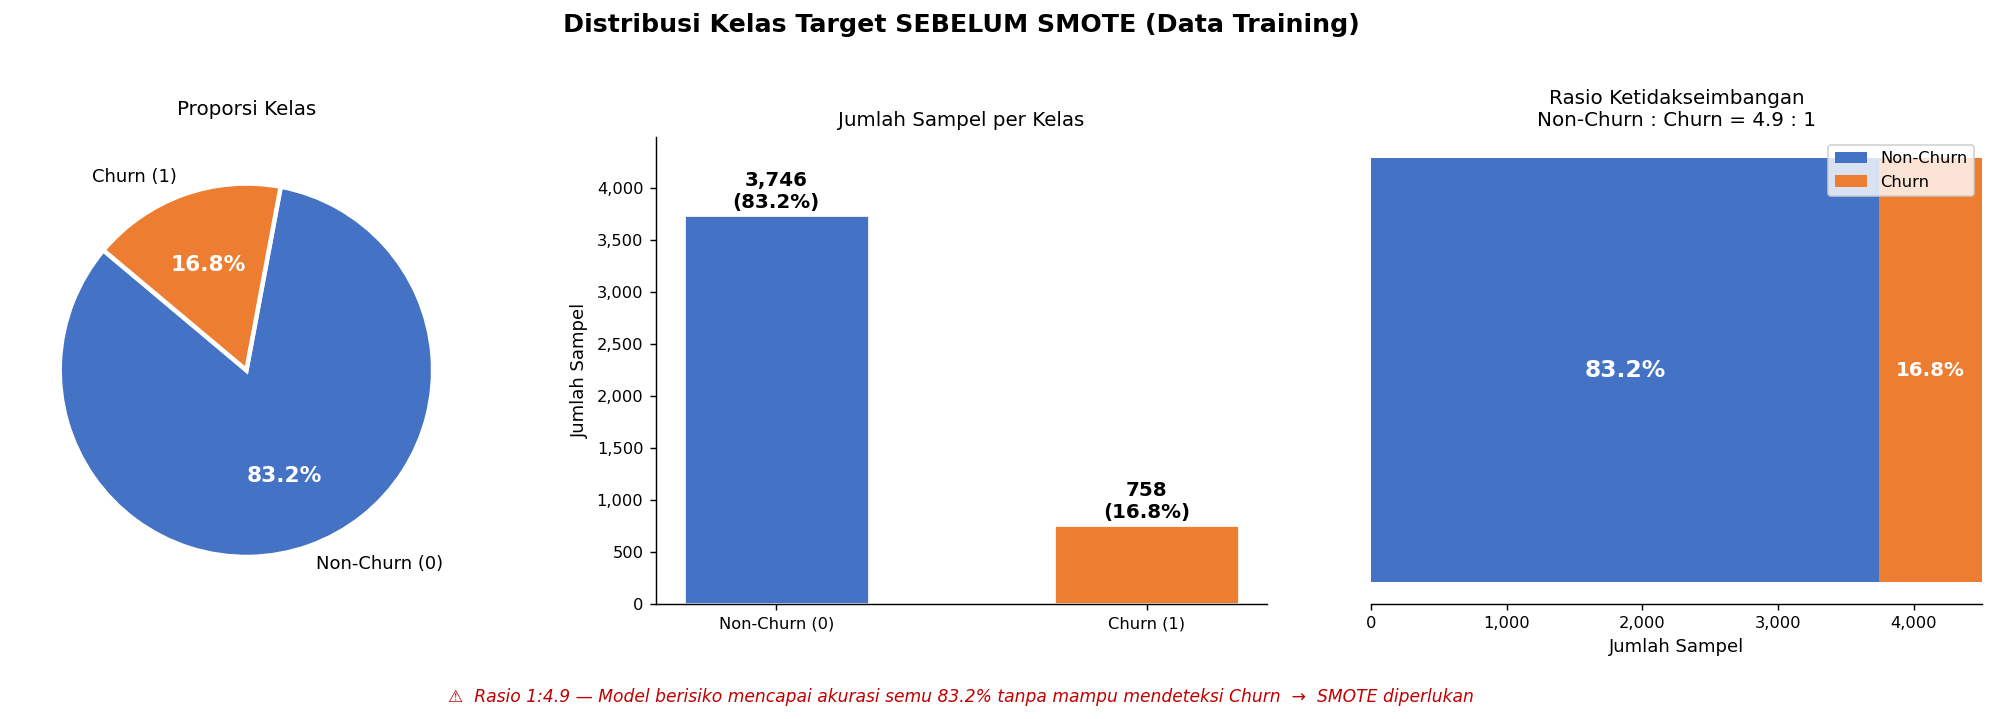

In [8]:
# ══════════════════════════════════════════════════════════════════
#  CELL 3.2 — Visualisasi Distribusi Sebelum SMOTE
#  3 panel: Pie chart | Bar chart | Gauge rasio
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Distribusi Kelas Target SEBELUM SMOTE (Data Training)',
    fontsize=14, fontweight='bold', y=1.02
)

labels  = ['Non-Churn (0)', 'Churn (1)']
sizes   = [n_majority, n_minority]
colors  = [C_MAJORITY, C_MINORITY]

# ── Panel 1: Pie chart ────────────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2.5),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
axes[0].set_title('Proporsi Kelas', fontsize=11, pad=12)

# ── Panel 2: Bar chart dengan anotasi ─────────────────────────────
bars = axes[1].bar(labels, sizes, color=colors, edgecolor='white',
                   linewidth=1.5, width=0.5)
for bar, sz, pct in zip(bars, sizes, [pct_maj, pct_min]):
    axes[1].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
        f'{sz:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[1].set_title('Jumlah Sampel per Kelas', fontsize=11)
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_ylim(0, max(sizes) * 1.2)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[1].spines[['top','right']].set_visible(False)

# ── Panel 3: Horizontal stacked bar "rasio visual" ────────────────
axes[2].barh([0], [n_majority], color=C_MAJORITY, label='Non-Churn')
axes[2].barh([0], [n_minority], left=[n_majority], color=C_MINORITY, label='Churn')
axes[2].set_xlim(0, total)
axes[2].set_yticks([])
axes[2].set_xlabel('Jumlah Sampel')
axes[2].set_title(f'Rasio Ketidakseimbangan\nNon-Churn : Churn = {ratio:.1f} : 1', fontsize=11)
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[2].legend(loc='upper right', fontsize=9)
axes[2].spines[['top','right','left']].set_visible(False)
# Anotasi di dalam bar
axes[2].text(n_majority/2,   0, f'{pct_maj:.1f}%', ha='center', va='center',
             color='white', fontsize=13, fontweight='bold')
axes[2].text(n_majority + n_minority/2, 0, f'{pct_min:.1f}%', ha='center',
             va='center', color='white', fontsize=11, fontweight='bold')

fig.text(
    0.5, -0.04,
    f'⚠  Rasio 1:{ratio:.1f} — Model berisiko mencapai akurasi semu {pct_maj:.1f}% '
    'tanpa mampu mendeteksi Churn  →  SMOTE diperlukan',
    ha='center', fontsize=9.5, color=C_DANGER, style='italic'
)

plt.tight_layout()
plt.savefig('ci_01_sebelum_smote.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.3 Simulasi Dampak Class Imbalance (Dummy Classifier)

In [9]:
# ══════════════════════════════════════════════════════════════════
#  CELL 3.3 — Simulasi Dummy Classifier
#  Membuktikan bahwa model "bodoh" yang selalu prediksi Non-Churn
#  bisa mendapat akurasi tinggi namun Recall Churn = 0%
# ══════════════════════════════════════════════════════════════════

from sklearn.dummy  import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)

# Scaler sementara untuk simulasi
_scaler = StandardScaler()
X_train_sc = _scaler.fit_transform(X_train)
X_test_sc  = _scaler.transform(X_test)

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_sc, y_train)
y_pred_dummy = dummy.predict(X_test_sc)

acc  = accuracy_score(y_test, y_pred_dummy)  * 100
prec = precision_score(y_test, y_pred_dummy, zero_division=0) * 100
rec  = recall_score(y_test, y_pred_dummy, zero_division=0)    * 100
f1   = f1_score(y_test, y_pred_dummy, zero_division=0)        * 100

print('╔══════════════════════════════════════════════════════════════╗')
print('║   SIMULASI: Dummy Classifier (Selalu Prediksi Non-Churn)    ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Accuracy   : {acc:.1f}%  ← terlihat tinggi!')
print(f'║  Precision  : {prec:.1f}%')
print(f'║  Recall     : {rec:.1f}%  ← gagal deteksi SEMUA Churn!')
print(f'║  F1-Score   : {f1:.1f}%  ← metrik utama proyek ini')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  KESIMPULAN: Akurasi BUKAN metrik yang tepat untuk data     ║')
print('║  tidak seimbang. F1-Score & Recall Churn = indikator utama  ║')
print('╚══════════════════════════════════════════════════════════════╝')
print()
print(classification_report(y_test, y_pred_dummy,
      target_names=['Non-Churn','Churn']))

╔══════════════════════════════════════════════════════════════╗
║   SIMULASI: Dummy Classifier (Selalu Prediksi Non-Churn)    ║
╠══════════════════════════════════════════════════════════════╣
║  Accuracy   : 83.1%  ← terlihat tinggi!
║  Precision  : 0.0%
║  Recall     : 0.0%  ← gagal deteksi SEMUA Churn!
║  F1-Score   : 0.0%  ← metrik utama proyek ini
╠══════════════════════════════════════════════════════════════╣
║  KESIMPULAN: Akurasi BUKAN metrik yang tepat untuk data     ║
║  tidak seimbang. F1-Score & Recall Churn = indikator utama  ║
╚══════════════════════════════════════════════════════════════╝

              precision    recall  f1-score   support

   Non-Churn       0.83      1.00      0.91       936
       Churn       0.00      0.00      0.00       190

    accuracy                           0.83      1126
   macro avg       0.42      0.50      0.45      1126
weighted avg       0.69      0.83      0.75      1126



---
## 4. Feature Scaling (StandardScaler)

In [10]:
# ══════════════════════════════════════════════════════════════════
#  CELL 4 — Feature Scaling (StandardScaler)
#  Scaler di-fit HANYA pada X_train agar tidak ada data leakage
# ══════════════════════════════════════════════════════════════════

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)    # fit + transform
X_test_sc  = scaler.transform(X_test)         # hanya transform

print('✅ Feature Scaling selesai (StandardScaler).')
print(f'   X_train_sc  : mean ≈ {X_train_sc.mean():.4f}  |  std ≈ {X_train_sc.std():.4f}')
print(f'   X_test_sc   : shape {X_test_sc.shape}')
print()
print('⚠  Catatan: scaler di-fit hanya pada data training')
print('   untuk menghindari data leakage ke data testing.')

✅ Feature Scaling selesai (StandardScaler).
   X_train_sc  : mean ≈ -0.0000  |  std ≈ 1.0000
   X_test_sc   : shape (1126, 18)

⚠  Catatan: scaler di-fit hanya pada data training
   untuk menghindari data leakage ke data testing.


---
## 5. Penerapan SMOTE pada Data Training

### 5.1 Dokumentasi Parameter SMOTE

In [11]:
# ══════════════════════════════════════════════════════════════════
#  CELL 5.1 — Dokumentasi Parameter SMOTE
# ══════════════════════════════════════════════════════════════════

SMOTE_PARAMS = {
    'sampling_strategy' : 'auto',    # buat kelas minoritas = kelas mayoritas
    'k_neighbors'       : 5,         # tetangga terdekat untuk buat titik sintetis
    'random_state'      : 42,        # reproducibility
    'n_jobs'            : -1,        # gunakan semua CPU
}

print('╔══════════════════════════════════════════════════════════════╗')
print('║            DOKUMENTASI PARAMETER SMOTE                     ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  Teknik   : SMOTE (Synthetic Minority Over-sampling)')
print('║  Library  : imbalanced-learn (imblearn.over_sampling)')
print('║')
print('║  Parameter:')
print(f'║  • sampling_strategy = "{SMOTE_PARAMS["sampling_strategy"]}"')
print('║    → Otomatis menyeimbangkan kelas minoritas (Churn)')
print('║      hingga jumlahnya sama dengan kelas mayoritas (Non-Churn)')
print(f'║  • k_neighbors = {SMOTE_PARAMS["k_neighbors"]}')
print('║    → SMOTE membuat titik sintetis di antara 5 tetangga')
print('║      terdekat (k-NN) dari setiap sampel minoritas')
print(f'║  • random_state = {SMOTE_PARAMS["random_state"]}')
print('║    → Memastikan hasil dapat direproduksi (reproducible)')
print(f'║  • n_jobs = {SMOTE_PARAMS["n_jobs"]}')
print('║    → Menggunakan semua core CPU yang tersedia')
print('║')
print('║  Cara kerja SMOTE:')
print('║  1. Pilih sampel dari kelas minoritas (Churn)')
print('║  2. Temukan k tetangga terdekat dalam ruang fitur')
print('║  3. Buat titik sintetis di sepanjang garis antara')
print('║     sampel asli dan tetangganya (interpolasi acak)')
print('║  4. Ulangi hingga kelas seimbang')
print('║')
print('║  ⚠  SMOTE HANYA diterapkan pada DATA TRAINING!')
print('║     Data testing dibiarkan asli (imbalanced) agar')
print('║     evaluasi mencerminkan kondisi data nyata.')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║            DOKUMENTASI PARAMETER SMOTE                     ║
╠══════════════════════════════════════════════════════════════╣
║  Teknik   : SMOTE (Synthetic Minority Over-sampling)
║  Library  : imbalanced-learn (imblearn.over_sampling)
║
║  Parameter:
║  • sampling_strategy = "auto"
║    → Otomatis menyeimbangkan kelas minoritas (Churn)
║      hingga jumlahnya sama dengan kelas mayoritas (Non-Churn)
║  • k_neighbors = 5
║    → SMOTE membuat titik sintetis di antara 5 tetangga
║      terdekat (k-NN) dari setiap sampel minoritas
║  • random_state = 42
║    → Memastikan hasil dapat direproduksi (reproducible)
║  • n_jobs = -1
║    → Menggunakan semua core CPU yang tersedia
║
║  Cara kerja SMOTE:
║  1. Pilih sampel dari kelas minoritas (Churn)
║  2. Temukan k tetangga terdekat dalam ruang fitur
║  3. Buat titik sintetis di sepanjang garis antara
║     sampel asli dan tetangganya (interpolasi acak)
║  4. Ulangi hingga kelas

### 5.2 Terapkan SMOTE

In [13]:
# ══════════════════════════════════════════════════════════════════
#  CELL 5.2 — Terapkan SMOTE pada Data Training
# ══════════════════════════════════════════════════════════════════
SMOTE_PARAMS = {
    'sampling_strategy' : 'auto',    # buat kelas minoritas = kelas mayoritas
    'k_neighbors'       : 5,         # tetangga terdekat untuk buat titik sintetis
    'random_state'      : 42,        # reproducibility
}

smote = SMOTE(**SMOTE_PARAMS)

print('⏳ Menerapkan SMOTE...')
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)

# Hitung distribusi setelah SMOTE
counter_before = Counter(y_train)
counter_after  = Counter(y_train_smote)

n_maj_after    = counter_after[0]
n_min_after    = counter_after[1]
n_synthetic    = n_min_after - counter_before[1]   # sampel sintetis yang dibuat
total_after    = len(y_train_smote)

print('\n✅ SMOTE berhasil diterapkan!')
print(f'\n   Sebelum SMOTE:')
print(f'     Non-Churn (0) : {counter_before[0]:,}  ({counter_before[0]/len(y_train)*100:.1f}%)')
print(f'     Churn     (1) : {counter_before[1]:,}  ({counter_before[1]/len(y_train)*100:.1f}%)')
print(f'     Total         : {len(y_train):,}')
print(f'\n   Sesudah SMOTE:')
print(f'     Non-Churn (0) : {n_maj_after:,}  ({n_maj_after/total_after*100:.1f}%)')
print(f'     Churn     (1) : {n_min_after:,}  ({n_min_after/total_after*100:.1f}%)')
print(f'     Total         : {total_after:,}')
print(f'\n   Sampel sintetis yang dibuat : {n_synthetic:,}')
print(f'   Penambahan data             : +{total_after - len(y_train):,} sampel')

⏳ Menerapkan SMOTE...

✅ SMOTE berhasil diterapkan!

   Sebelum SMOTE:
     Non-Churn (0) : 3,746  (83.2%)
     Churn     (1) : 758  (16.8%)
     Total         : 4,504

   Sesudah SMOTE:
     Non-Churn (0) : 3,746  (50.0%)
     Churn     (1) : 3,746  (50.0%)
     Total         : 7,492

   Sampel sintetis yang dibuat : 2,988
   Penambahan data             : +2,988 sampel


---
## 6. Evaluasi Hasil Oversampling

### 6.1 Perbandingan Distribusi Sebelum vs Sesudah SMOTE

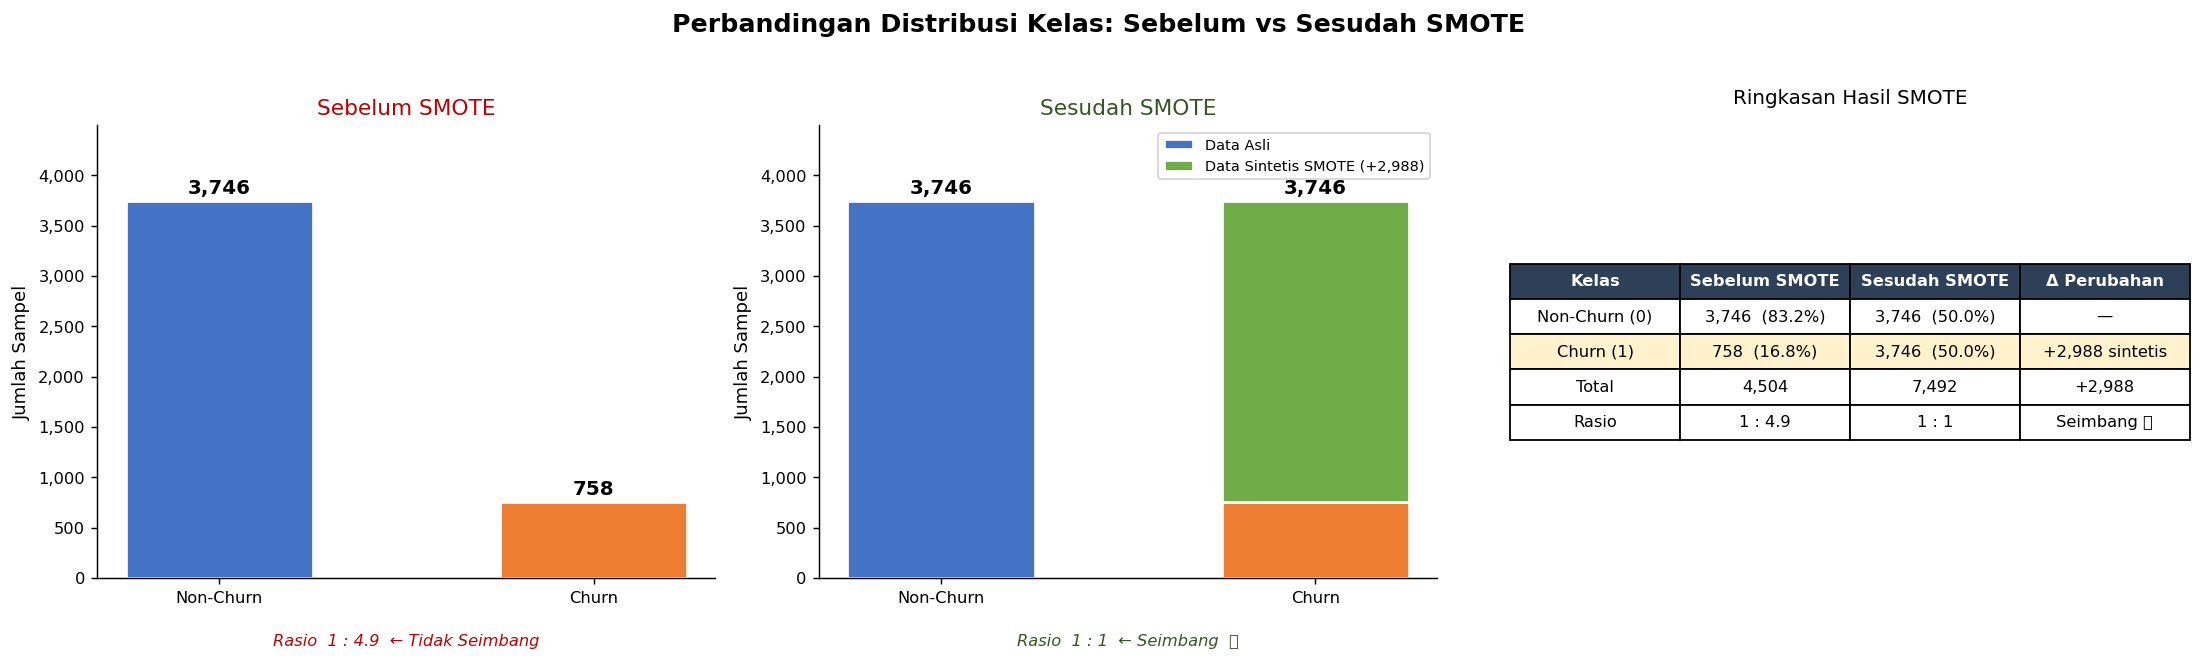

In [14]:
# ══════════════════════════════════════════════════════════════════
#  CELL 6.1 — Perbandingan Distribusi Sebelum vs Sesudah SMOTE
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    'Perbandingan Distribusi Kelas: Sebelum vs Sesudah SMOTE',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Panel 1: Sebelum SMOTE ────────────────────────────────────────
vals_b = [counter_before[0], counter_before[1]]
bars_b = axes[0].bar(['Non-Churn', 'Churn'], vals_b,
                      color=[C_MAJORITY, C_MINORITY],
                      edgecolor='white', linewidth=1.5, width=0.5)
for bar, v in zip(bars_b, vals_b):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Sebelum SMOTE', fontsize=12, color=C_DANGER)
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, max(vals_b)*1.2)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].spines[['top','right']].set_visible(False)
axes[0].text(0.5, -0.15, f'Rasio  1 : {ratio:.1f}  ← Tidak Seimbang',
             transform=axes[0].transAxes, ha='center',
             fontsize=9, color=C_DANGER, style='italic')

# ── Panel 2: Sesudah SMOTE ────────────────────────────────────────
vals_a = [n_maj_after, n_min_after]
# Stacked bar: asli + sintetis untuk kelas Churn
axes[1].bar(['Non-Churn', 'Churn'],
             [n_maj_after, counter_before[1]],
             color=[C_MAJORITY, C_MINORITY], edgecolor='white', linewidth=1.5, width=0.5,
             label='Data Asli')
axes[1].bar(['Churn'], [n_synthetic],
             bottom=[counter_before[1]],
             color=C_SMOTE, edgecolor='white', linewidth=1.5, width=0.5,
             label=f'Data Sintetis SMOTE (+{n_synthetic:,})')
for v, xpos in zip(vals_a, [0, 1]):
    axes[1].text(xpos, v+30, f'{v:,}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[1].set_title('Sesudah SMOTE', fontsize=12, color='#375623')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_ylim(0, max(vals_a)*1.2)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[1].spines[['top','right']].set_visible(False)
axes[1].legend(fontsize=8, loc='upper right')
axes[1].text(0.5, -0.15, 'Rasio  1 : 1  ← Seimbang  ✅',
             transform=axes[1].transAxes, ha='center',
             fontsize=9, color='#375623', style='italic')

# ── Panel 3: Ringkasan Tabel ──────────────────────────────────────
axes[2].axis('off')
table_data = [
    ['Kelas',         'Sebelum SMOTE', 'Sesudah SMOTE', 'Δ Perubahan'],
    ['Non-Churn (0)', f'{counter_before[0]:,}  ({counter_before[0]/len(y_train)*100:.1f}%)',
                      f'{n_maj_after:,}  ({n_maj_after/total_after*100:.1f}%)',  '—'],
    ['Churn (1)',      f'{counter_before[1]:,}  ({counter_before[1]/len(y_train)*100:.1f}%)',
                      f'{n_min_after:,}  ({n_min_after/total_after*100:.1f}%)',
                       f'+{n_synthetic:,} sintetis'],
    ['Total',          f'{len(y_train):,}', f'{total_after:,}',
                       f'+{total_after - len(y_train):,}'],
    ['Rasio',          f'1 : {ratio:.1f}',  '1 : 1',           'Seimbang ✅'],
]

tbl = axes[2].table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.8)
# Warna header
for j in range(4):
    tbl[(0, j)].set_facecolor('#2E4057')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
# Warna baris Churn
for j in range(4):
    tbl[(2, j)].set_facecolor('#FFF2CC')
axes[2].set_title('Ringkasan Hasil SMOTE', fontsize=11, pad=12)

plt.tight_layout()
plt.savefig('ci_02_sebelum_vs_sesudah_smote.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.2 Visualisasi PCA 2D — Sebaran Data Sebelum vs Sesudah SMOTE

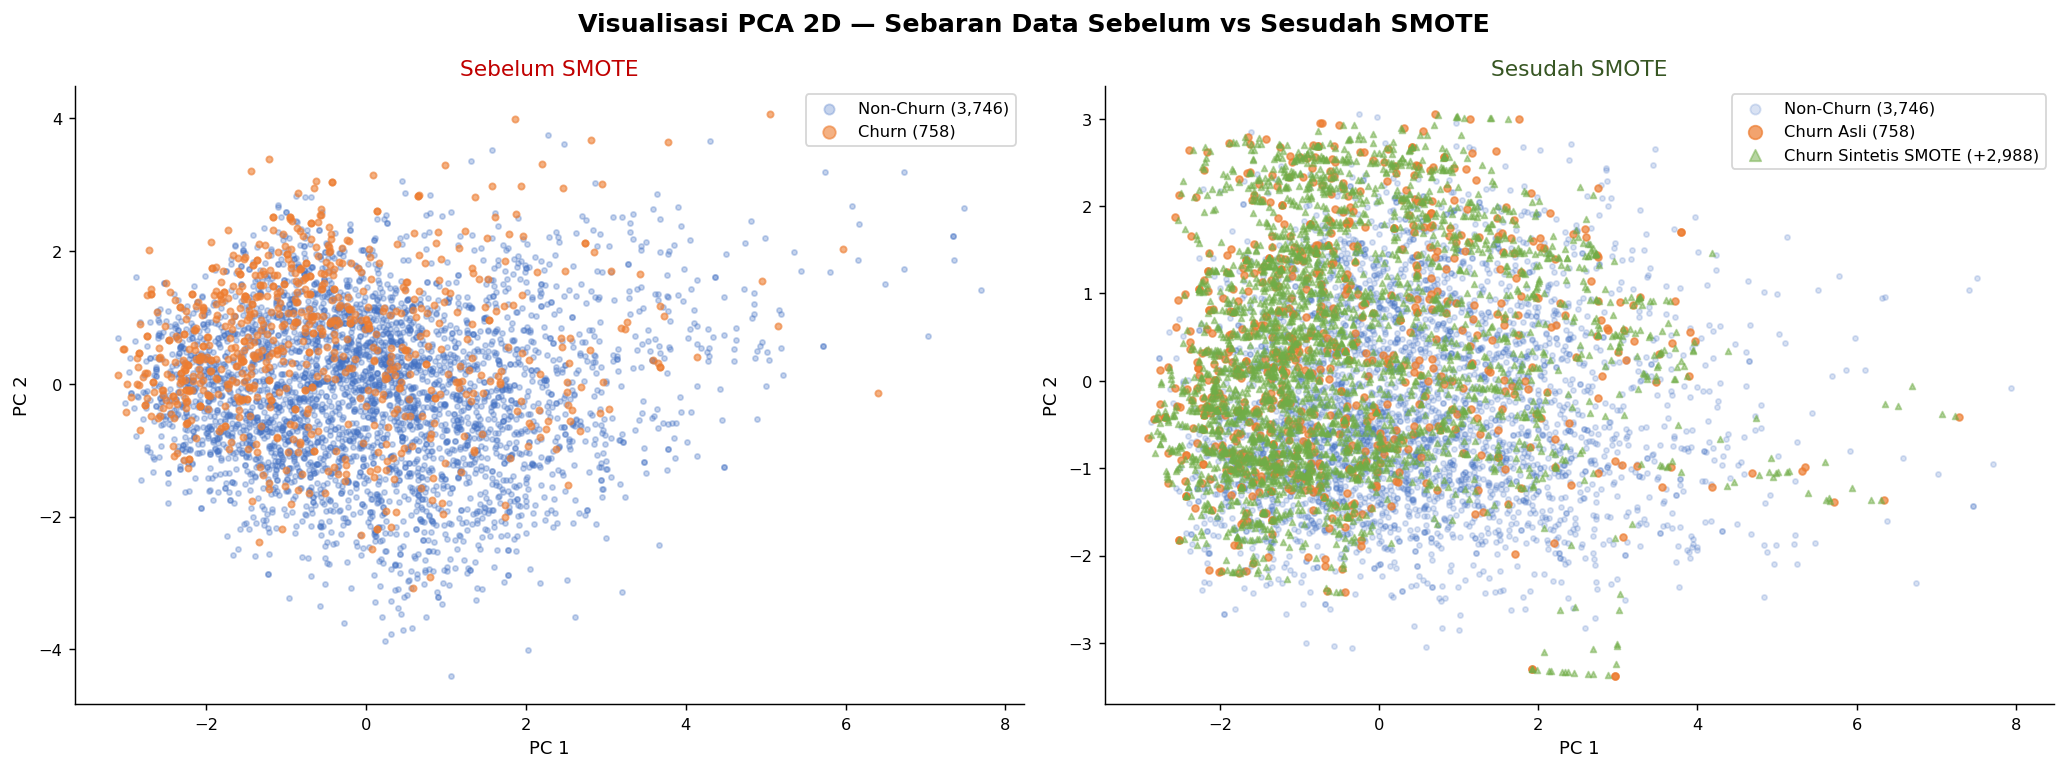

PCA menjelaskan varians:  PC1 = 14.7%  |  PC2 = 8.4%


In [15]:
# ══════════════════════════════════════════════════════════════════
#  CELL 6.2 — Visualisasi PCA 2D
#  Mereduksi dimensi ke 2D untuk melihat sebaran data
#  secara visual: asli vs sesudah SMOTE
# ══════════════════════════════════════════════════════════════════

pca = PCA(n_components=2, random_state=42)

# PCA untuk data sebelum SMOTE
pca_before = pca.fit_transform(X_train_sc)

# PCA untuk data sesudah SMOTE (fit ulang agar skala sama)
pca2       = PCA(n_components=2, random_state=42)
pca_after  = pca2.fit_transform(X_train_smote)

# Identifikasi titik sintetis (semua baris setelah indeks len(X_train_sc))
idx_original_churn   = np.where(y_train.values == 1)[0]
n_orig_churn         = len(idx_original_churn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Visualisasi PCA 2D — Sebaran Data Sebelum vs Sesudah SMOTE',
    fontsize=14, fontweight='bold'
)

# ── Panel kiri: Sebelum SMOTE ─────────────────────────────────────
mask0_b = y_train.values == 0
mask1_b = y_train.values == 1
axes[0].scatter(pca_before[mask0_b, 0], pca_before[mask0_b, 1],
                c=C_MAJORITY, alpha=0.3, s=8, label=f'Non-Churn ({mask0_b.sum():,})')
axes[0].scatter(pca_before[mask1_b, 0], pca_before[mask1_b, 1],
                c=C_MINORITY, alpha=0.6, s=12, label=f'Churn ({mask1_b.sum():,})')
axes[0].set_title('Sebelum SMOTE', fontsize=12, color=C_DANGER)
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')
axes[0].legend(markerscale=2)
axes[0].spines[['top','right']].set_visible(False)

# ── Panel kanan: Sesudah SMOTE ────────────────────────────────────
mask0_a = y_train_smote == 0
mask1_a = y_train_smote == 1
# Data Churn asli vs sintetis
all_churn_idx = np.where(mask1_a)[0]
orig_churn_idx = all_churn_idx[:n_orig_churn]
synt_churn_idx = all_churn_idx[n_orig_churn:]

axes[1].scatter(pca_after[mask0_a, 0],        pca_after[mask0_a, 1],
                c=C_MAJORITY, alpha=0.2, s=8,  label=f'Non-Churn ({mask0_a.sum():,})')
axes[1].scatter(pca_after[orig_churn_idx, 0], pca_after[orig_churn_idx, 1],
                c=C_MINORITY, alpha=0.7, s=14, label=f'Churn Asli ({n_orig_churn:,})')
axes[1].scatter(pca_after[synt_churn_idx, 0], pca_after[synt_churn_idx, 1],
                c=C_SMOTE,   alpha=0.5, s=10, marker='^',
                label=f'Churn Sintetis SMOTE (+{n_synthetic:,})')
axes[1].set_title('Sesudah SMOTE', fontsize=12, color='#375623')
axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')
axes[1].legend(markerscale=2)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('ci_03_pca_smote.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'PCA menjelaskan varians:  PC1 = {pca2.explained_variance_ratio_[0]*100:.1f}%  |  PC2 = {pca2.explained_variance_ratio_[1]*100:.1f}%')

### 6.3 Distribusi Fitur Utama — Asli vs Sintetis SMOTE

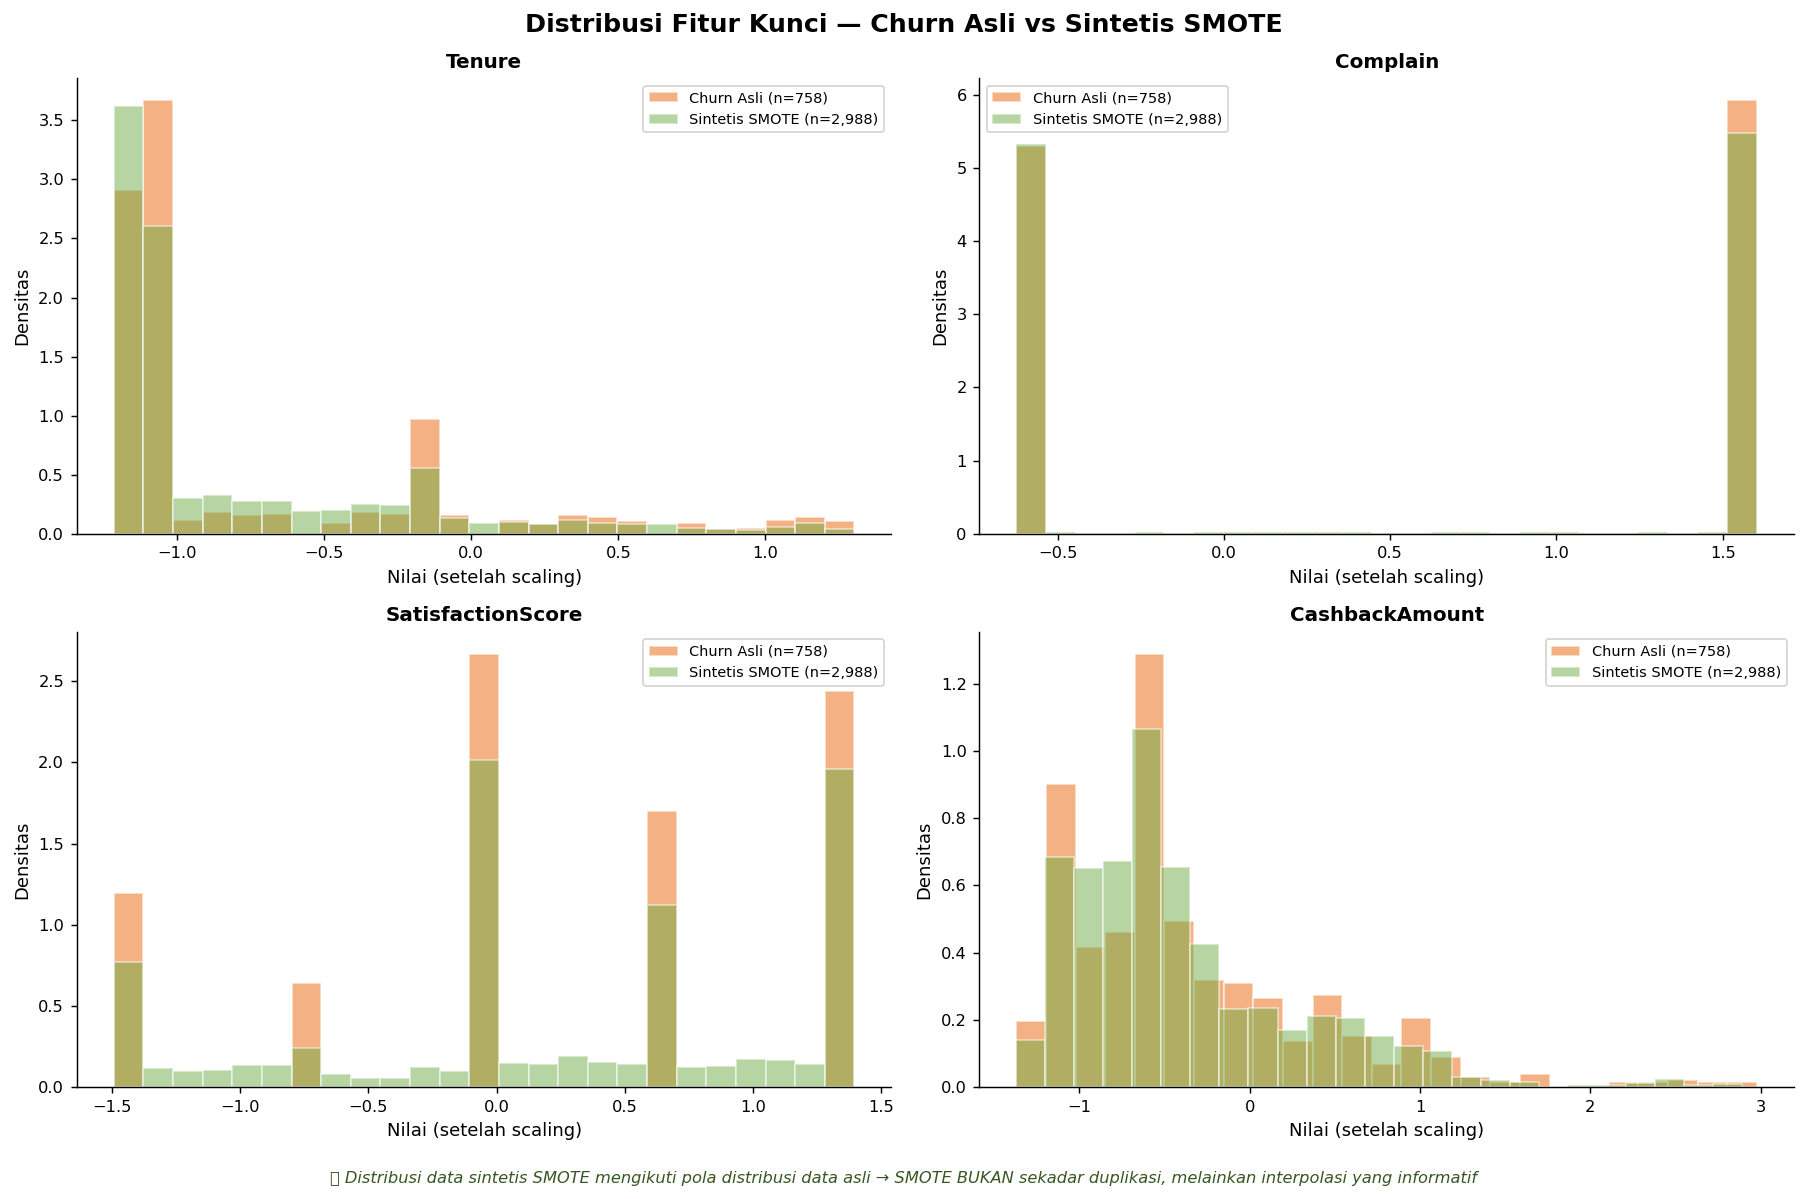

In [16]:
# ══════════════════════════════════════════════════════════════════
#  CELL 6.3 — Distribusi Fitur Utama: Data Asli vs Sintetis SMOTE
#  Membuktikan SMOTE menghasilkan distribusi yang wajar
#  (bukan sekadar duplikasi)
# ══════════════════════════════════════════════════════════════════

# Pilih 4 fitur paling korelasi dengan Churn (dari BAB II laporan)
key_features = ['Tenure', 'Complain', 'SatisfactionScore', 'CashbackAmount']
key_features = [f for f in key_features if f in X_train.columns]

# Rekonstruksi DataFrame setelah SMOTE untuk analisis
df_smote_all = pd.DataFrame(X_train_smote, columns=X_train.columns)
df_smote_all['Churn'] = y_train_smote.values

# Pisah: data churn asli vs sintetis
churn_mask_smote  = df_smote_all['Churn'] == 1
churn_asli_idx    = churn_mask_smote[churn_mask_smote].index[:n_orig_churn]
churn_sintetis_idx= churn_mask_smote[churn_mask_smote].index[n_orig_churn:]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Distribusi Fitur Kunci — Churn Asli vs Sintetis SMOTE',
    fontsize=14, fontweight='bold'
)
axes_flat = axes.flatten()

for ax, feat in zip(axes_flat, key_features):
    orig = df_smote_all.loc[churn_asli_idx,    feat]
    synt = df_smote_all.loc[churn_sintetis_idx, feat]

    ax.hist(orig, bins=25, alpha=0.6, color=C_MINORITY, density=True,
            label=f'Churn Asli (n={len(orig):,})', edgecolor='white')
    ax.hist(synt, bins=25, alpha=0.5, color=C_SMOTE,   density=True,
            label=f'Sintetis SMOTE (n={len(synt):,})', edgecolor='white')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('Nilai (setelah scaling)')
    ax.set_ylabel('Densitas')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

fig.text(
    0.5, -0.02,
    '✅ Distribusi data sintetis SMOTE mengikuti pola distribusi data asli → '  
    'SMOTE BUKAN sekadar duplikasi, melainkan interpolasi yang informatif',
    ha='center', fontsize=9, style='italic', color='#375623'
)

plt.tight_layout()
plt.savefig('ci_04_distribusi_fitur_smote.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Ringkasan Lengkap & Verifikasi Akhir

In [17]:
# ══════════════════════════════════════════════════════════════════
#  CELL 7 — Ringkasan Lengkap & Verifikasi Akhir
# ══════════════════════════════════════════════════════════════════

print('╔═══════════════════════════════════════════════════════════════╗')
print('║       RINGKASAN — DATA PREPARATION: CLASS IMBALANCE & SMOTE  ║')
print('╠═══════════════════════════════════════════════════════════════╣')
print('║  TAHAP PRE-PROCESSING:')
print('║  ✅  Cleaning dirty data (CC→Credit Card, Mobile→Mobile Phone)')
print('║  ✅  Imputasi missing values dengan median (7 kolom)')
print('║  ✅  Label Encoding kolom kategorikal')
print('║  ✅  Drop kolom CustomerID (tidak relevan)')
print('║  ✅  Train-Test Split stratified 80:20')
print('║  ✅  Feature Scaling dengan StandardScaler')
print('╠═══════════════════════════════════════════════════════════════╣')
print('║  CLASS IMBALANCE (sebelum SMOTE):')
print(f'║     Non-Churn  : {counter_before[0]:,}  ({counter_before[0]/len(y_train)*100:.1f}%)')
print(f'║     Churn      : {counter_before[1]:,}  ({counter_before[1]/len(y_train)*100:.1f}%)')
print(f'║     Rasio      : 1 : {ratio:.1f}  ← Tidak Seimbang')
print('╠═══════════════════════════════════════════════════════════════╣')
print('║  SMOTE DITERAPKAN:')
print(f'║     Sampel sintetis dibuat : {n_synthetic:,}')
print(f'║     Parameter  : k_neighbors=5, random_state=42')
print('╠═══════════════════════════════════════════════════════════════╣')
print('║  HASIL SETELAH SMOTE:')
print(f'║     Non-Churn  : {n_maj_after:,}  ({n_maj_after/total_after*100:.1f}%)')
print(f'║     Churn      : {n_min_after:,}  ({n_min_after/total_after*100:.1f}%)')
print(f'║     Rasio      : 1 : 1  ← Seimbang ✅')
print(f'║     Total data training baru : {total_after:,} sampel')
print('╠═══════════════════════════════════════════════════════════════╣')
print('║  VERIFIKASI OUTPUT:')
print(f'║     X_train_smote shape : {X_train_smote.shape}')
print(f'║     y_train_smote shape : {y_train_smote.shape}')
print(f'║     X_test shape        : {X_test_sc.shape}  (tidak diubah SMOTE)')
print(f'║     y_test shape        : {y_test.shape}    (tidak diubah SMOTE)')
print('╠═══════════════════════════════════════════════════════════════╣')
print('║  OUTPUT UNTUK TAHAP SELANJUTNYA (Modeling):')
print('║     → X_train_smote  (fitur training, sudah SMOTE + scaled)')
print('║     → y_train_smote  (label training, sudah seimbang)')
print('║     → X_test_sc      (fitur testing, hanya scaled)')
print('║     → y_test         (label testing, asli / imbalanced)')
print('╚═══════════════════════════════════════════════════════════════╝')

# Konfirmasi distribusi akhir
assert Counter(y_train_smote)[0] == Counter(y_train_smote)[1], \
    '❌ Distribusi belum seimbang! Periksa parameter SMOTE.'
print('\n✅ Verifikasi: kelas sudah seimbang sempurna (50% : 50%)')

╔═══════════════════════════════════════════════════════════════╗
║       RINGKASAN — DATA PREPARATION: CLASS IMBALANCE & SMOTE  ║
╠═══════════════════════════════════════════════════════════════╣
║  TAHAP PRE-PROCESSING:
║  ✅  Cleaning dirty data (CC→Credit Card, Mobile→Mobile Phone)
║  ✅  Imputasi missing values dengan median (7 kolom)
║  ✅  Label Encoding kolom kategorikal
║  ✅  Drop kolom CustomerID (tidak relevan)
║  ✅  Train-Test Split stratified 80:20
║  ✅  Feature Scaling dengan StandardScaler
╠═══════════════════════════════════════════════════════════════╣
║  CLASS IMBALANCE (sebelum SMOTE):
║     Non-Churn  : 3,746  (83.2%)
║     Churn      : 758  (16.8%)
║     Rasio      : 1 : 4.9  ← Tidak Seimbang
╠═══════════════════════════════════════════════════════════════╣
║  SMOTE DITERAPKAN:
║     Sampel sintetis dibuat : 2,988
║     Parameter  : k_neighbors=5, random_state=42
╠═══════════════════════════════════════════════════════════════╣
║  HASIL SETELAH SMOTE:
║     Non-Churn 

---
## 8. Simpan Output untuk Tahap Modeling

In [18]:
# ══════════════════════════════════════════════════════════════════
#  CELL 8 — Simpan Output ke File .npy & .csv
#  (opsional — gunakan jika ingin dipakai di notebook lain)
# ══════════════════════════════════════════════════════════════════
import os

# Buat folder output jika belum ada
os.makedirs('output_smote', exist_ok=True)

# Simpan sebagai numpy array
np.save('output_smote/X_train_smote.npy', X_train_smote)
np.save('output_smote/y_train_smote.npy', y_train_smote)
np.save('output_smote/X_test_sc.npy',     X_test_sc)
np.save('output_smote/y_test.npy',        y_test.values)

# Simpan sebagai CSV (lebih mudah dibaca)
pd.DataFrame(X_train_smote, columns=X_train.columns).assign(Churn=y_train_smote) \
  .to_csv('output_smote/train_smote.csv', index=False)

pd.DataFrame(X_test_sc, columns=X_test.columns).assign(Churn=y_test.values) \
  .to_csv('output_smote/test.csv', index=False)

print('✅ File berhasil disimpan di folder output_smote/:')
for f in os.listdir('output_smote'):
    size = os.path.getsize(f'output_smote/{f}') / 1024
    print(f'   {f:<30}  {size:.1f} KB')

✅ File berhasil disimpan di folder output_smote/:
   test.csv                        393.5 KB
   train_smote.csv                 2614.2 KB
   X_test_sc.npy                   158.5 KB
   X_train_smote.npy               1053.7 KB
   y_test.npy                      8.9 KB
   y_train_smote.npy               58.7 KB
